# 1. Proje ve Problem Tanımı

Customer Churn (müşteri kaybı), bir müşterinin işletmenin ürün veya hizmetini kullanmayı bırakmasıdır. Mevcut bir müşteriyi kaybetmek gelir kaybına yol açabileceği ve yeni müşteri kazanmak ek maliyet oluşturabileceği için churn işletmeler açısından önemli bir konudur.

Bu projede müşterilerin demografik, hizmet, abonelik ve ödeme bilgileri incelenerek müşterinin ayrılıp ayrılmadığı anlaşılmaya çalışılacaktır. Bu, iki olası sonucu bulunan bir **sınıflandırma (classification)** problemidir. Hedef değişken `Churn` sütunudur: `Yes` müşterinin ayrıldığını, `No` ise ayrılmadığını ifade eder.

# 2. Veri Setinin Tanıtılması

IBM Telco Customer Churn veri setinde her satır bir müşteriyi temsil eder. Sütunlar; müşteri özelliklerini, kullanılan telefon ve internet hizmetlerini, abonelik ve ödeme bilgilerini ve müşterinin ayrılma durumunu içerir.

In [1]:
import pandas as pd

data_path = "data/Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(f"Veri setinin boyutu: {df.shape[0]} satır × {df.shape[1]} sütun")
print("\nSütun isimleri:")
print(df.columns.tolist())

Veri setinin boyutu: 7043 satır × 21 sütun

Sütun isimleri:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
df.dtypes.rename("Veri Tipi").to_frame()

,Veri Tipi
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`info()` çıktısına göre tüm sütunlarda 7.043 dolu kayıt görünmektedir. Ancak metin sütunlarında standart eksik değer olarak algılanmayan boş veya yalnızca boşluk içeren değerler ayrıca kontrol edilmelidir.

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.16,0.37,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.37,24.56,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.5,70.35,89.85,118.75


## Değişken Grupları

### Müşteri bilgileri

- `customerID`: Her müşteriye ait benzersiz kimlik.
- `gender`: Müşterinin cinsiyeti.
- `SeniorCitizen`: Müşterinin yaşlı vatandaş olup olmadığını gösteren 0/1 kodu.
- `Partner`: Müşterinin eşi veya partneri olup olmadığı.
- `Dependents`: Müşterinin bakmakla yükümlü olduğu kişiler olup olmadığı.

### Hizmet bilgileri

- `PhoneService` ve `MultipleLines`: Telefon hizmeti ve birden fazla hat kullanımı.
- `InternetService`: İnternet hizmetinin türü.
- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection` ve `TechSupport`: İnternet güvenliği, yedekleme, cihaz koruma ve teknik destek hizmetleri.
- `StreamingTV` ve `StreamingMovies`: TV ve film yayın hizmetleri.

### Abonelik ve ödeme bilgileri

- `tenure`: Müşterinin şirkette kaldığı ay sayısı.
- `Contract`: Sözleşme türü.
- `PaperlessBilling`: Kağıtsız fatura kullanımı.
- `PaymentMethod`: Ödeme yöntemi.
- `MonthlyCharges` ve `TotalCharges`: Aylık ücret ve toplam ücret.

### Hedef

- `Churn`: Müşterinin ayrılıp ayrılmadığını gösteren hedef değişken (`Yes` / `No`).

# 3. Keşifsel Veri Analizi

Bu bölümde veri setinin yapısı ve temel veri kalitesi incelenmektedir. Tespit edilen sorunlar yalnızca not edilecek; bu aşamada veri temizleme veya kalıcı veri tipi dönüşümü yapılmayacaktır.

## Eksik ve Boş Değer Kontrolü

In [6]:
text_columns = df.select_dtypes(include=["object", "string"]).columns

missing_summary = pd.DataFrame({
    "Standart Eksik Değer (NaN)": df.isna().sum(),
    "Boş veya Yalnızca Boşluk": [
        df[column].astype("string").str.strip().eq("").sum()
        if column in text_columns else 0
        for column in df.columns
    ],
})

missing_summary

,Standart Eksik Değer (NaN),Boş veya Yalnızca Boşluk
customerID,0,0
gender,0,0
SeniorCitizen,0,0
Partner,0,0
Dependents,0,0
tenure,0,0
PhoneService,0,0
MultipleLines,0,0
InternetService,0,0
OnlineSecurity,0,0


Standart `NaN` kontrolünde eksik değer bulunmamıştır. Buna karşılık `TotalCharges` sütununda **11 adet yalnızca boşluk içeren değer** vardır. Bu değerler pandas tarafından standart eksik değer olarak sayılmamaktadır. Temizleme işlemi veri ön işleme aşamasına bırakılmıştır.

## Tekrarlanan Kayıt Kontrolü

In [7]:
duplicate_summary = pd.DataFrame({
    "Kontrol": ["Tekrarlanan tam satır", "Tekrarlanan customerID"],
    "Sayı": [df.duplicated().sum(), df["customerID"].duplicated().sum()],
})

duplicate_summary

,Kontrol,Sayı
0,Tekrarlanan tam satır,0
1,Tekrarlanan customerID,0


Veri setinde tekrarlanan tam satır veya tekrarlanan `customerID` bulunmamıştır.

## Kategorik Değişkenlerin Benzersiz Değerleri

`SeniorCitizen` sayısal saklansa da 0/1 ile iki grubu temsil ettiği için bu özette kategorik bir değişken olarak ele alınmıştır. Benzersiz müşteri kimliği olan `customerID` ve sayısal görünmesi beklenen `TotalCharges` bu listenin dışında tutulmuştur.

In [8]:
categorical_columns = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "Churn",
]

categorical_unique_summary = pd.DataFrame({
    "Sütun": categorical_columns,
    "Benzersiz Değer Sayısı": [df[column].nunique() for column in categorical_columns],
    "Değerler": [
        ", ".join(map(str, df[column].unique()))
        for column in categorical_columns
    ],
})

categorical_unique_summary

,Sütun,Benzersiz Değer Sayısı,Değerler
0,gender,2,"Female, Male"
1,SeniorCitizen,2,"0, 1"
2,Partner,2,"Yes, No"
3,Dependents,2,"No, Yes"
4,PhoneService,2,"No, Yes"
5,MultipleLines,3,"No phone service, No, Yes"
6,InternetService,3,"DSL, Fiber optic, No"
7,OnlineSecurity,3,"No, Yes, No internet service"
8,OnlineBackup,3,"Yes, No, No internet service"
9,DeviceProtection,3,"No, Yes, No internet service"


## Churn Dağılımı

In [9]:
churn_distribution = pd.DataFrame({
    "Adet": df["Churn"].value_counts(),
    "Yüzde (%)": df["Churn"].value_counts(normalize=True).mul(100).round(2),
})
churn_distribution.index.name = "Churn"

churn_distribution

,Adet,Yüzde (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


Müşterilerin %73,46'sı ayrılmamış (`No`), %26,54'ü ayrılmıştır (`Yes`). `No` sınıfı belirgin biçimde daha büyüktür; dolayısıyla sınıflar tam dengeli değildir. Bu fark, ileride model değerlendirilirken yalnızca genel doğruluğa değil sınıf bazlı değerlendirme ölçülerine de bakmanın önemli olabileceğini gösterir. Bu aşamada herhangi bir modelleme kararı verilmemektedir.

## Seçili Kategorik Değişkenler

Aşağıdaki sayımlar veri setindeki bazı önemli kategorik değişkenlerin yapısını özetler.

In [10]:
selected_categorical_columns = [
    "Contract", "InternetService", "PaymentMethod", "gender", "SeniorCitizen"
]

selected_count_tables = []
for column in selected_categorical_columns:
    counts = df[column].value_counts()
    selected_count_tables.append(pd.DataFrame({
        "Değişken": column,
        "Değer": counts.index.astype(str),
        "Adet": counts.values,
        "Yüzde (%)": (counts.values / len(df) * 100).round(2),
    }))

selected_category_counts = pd.concat(selected_count_tables, ignore_index=True)
selected_category_counts

,Değişken,Değer,Adet,Yüzde (%)
0,Contract,Month-to-month,3875,55.02
1,Contract,Two year,1695,24.07
2,Contract,One year,1473,20.91
3,InternetService,Fiber optic,3096,43.96
4,InternetService,DSL,2421,34.37
5,InternetService,No,1526,21.67
6,PaymentMethod,Electronic check,2365,33.58
7,PaymentMethod,Mailed check,1612,22.89
8,PaymentMethod,Bank transfer (automatic),1544,21.92
9,PaymentMethod,Credit card (automatic),1522,21.61


## Sayısal Değişkenlerin Özeti

`tenure` ve `MonthlyCharges` sütunları doğrudan sayısal veri tipindedir. Temel istatistikleri aşağıda gösterilmiştir.

In [11]:
numeric_summary = (
    df[["tenure", "MonthlyCharges"]]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
    .round(2)
)

numeric_summary

,count,mean,std,min,median,max
tenure,7043.0,32.37,24.56,0.00,29.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,70.35,118.75


### TotalCharges Kontrolü

`TotalCharges` toplam ücret bilgisini içermesine rağmen metin (`str`) veri tipindedir. Yalnızca boşluk içeren 11 kayıt bu sütunun doğrudan sayısal olarak incelenmesini engeller. Aşağıdaki dönüşüm sadece problemi ölçmek için geçici bir seri üzerinde yapılır; özgün `df["TotalCharges"]` sütunu değiştirilmez. Kalıcı dönüşüm ve eksik değer işlemi veri ön işleme aşamasına bırakılmıştır.

In [12]:
total_charges_numeric_check = pd.to_numeric(df["TotalCharges"], errors="coerce")
total_charges_summary = (
    total_charges_numeric_check
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename("Değer")
    .to_frame()
    .round(2)
)

print(f"Özgün TotalCharges veri tipi: {df['TotalCharges'].dtype}")
print(f"Sayısala dönüşemeyen değer sayısı: {total_charges_numeric_check.isna().sum()}")
total_charges_summary

Özgün TotalCharges veri tipi: str
Sayısala dönüşemeyen değer sayısı: 11


,Değer
count,7032.00
mean,2283.30
std,2266.77
min,18.80
median,1397.48
max,8684.80


### İlk Bulgular

- Veri seti 7.043 müşteri ve 21 sütundan oluşmaktadır. Sütunlarda metin, tam sayı ve ondalıklı sayı veri tipleri bulunmaktadır.
- Standart eksik değer (`NaN`) yoktur; ancak `TotalCharges` sütununda standart kontrolde görünmeyen 11 adet yalnızca boşluk içeren değer vardır.
- Tekrarlanan tam satır ve tekrarlanan müşteri kimliği bulunmamıştır.
- `Churn` dağılımında `No` 5.174 (%73,46), `Yes` 1.869 (%26,54) kayıttır; sınıflar arasında belirgin bir sayı farkı vardır.
- `TotalCharges` metin tipindedir. Geçici sayısal kontrolde 7.032 değer analiz edilebilmiştir; kalıcı dönüşüm veri ön işleme aşamasına bırakılmıştır.

# 4. Veri Görselleştirme

Bu bölümde müşteri kaybı ile bazı önemli değişkenler arasındaki görünen ilişkiler basit grafiklerle incelenmektedir. Her grafik hem notebook içinde gösterilecek hem de `outputs/figures/` klasörüne PNG olarak kaydedilecektir. Grafiklerde yalnızca gözlenen desenler yorumlanacaktır.

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

churn_order = ["No", "Yes"]
churn_colors = {"No": "#4C72B0", "Yes": "#DD8452"}
rate_color = "#55A868"

## Churn Dağılımı

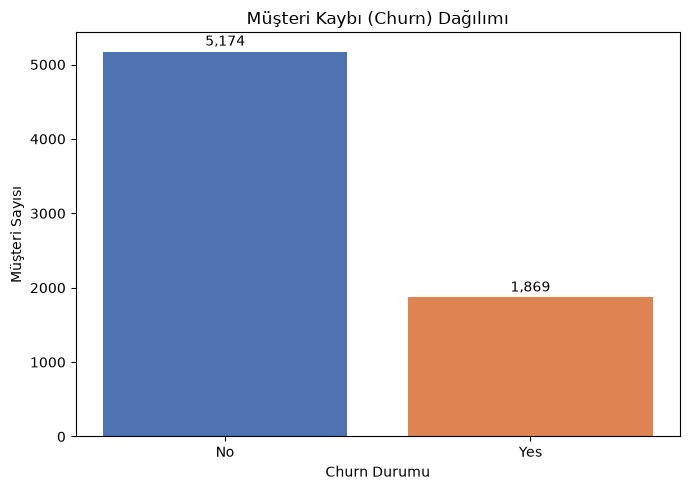

In [14]:
churn_counts = df["Churn"].value_counts().reindex(churn_order)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    churn_counts.index,
    churn_counts.values,
    color=[churn_colors[status] for status in churn_counts.index],
)

for bar, value in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 80, f"{value:,}", ha="center")

ax.set_title("Müşteri Kaybı (Churn) Dağılımı")
ax.set_xlabel("Churn Durumu")
ax.set_ylabel("Müşteri Sayısı")
fig.tight_layout()
fig.savefig(figures_dir / "churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

Veri setinde churn etmeyen müşteriler 5.174 kişi ile çoğunluktadır (%73,46). Churn eden müşteri sayısı 1.869'dur (%26,54); bu nedenle hedef sınıfları tam dengeli değildir.

## Contract ile Churn İlişkisi

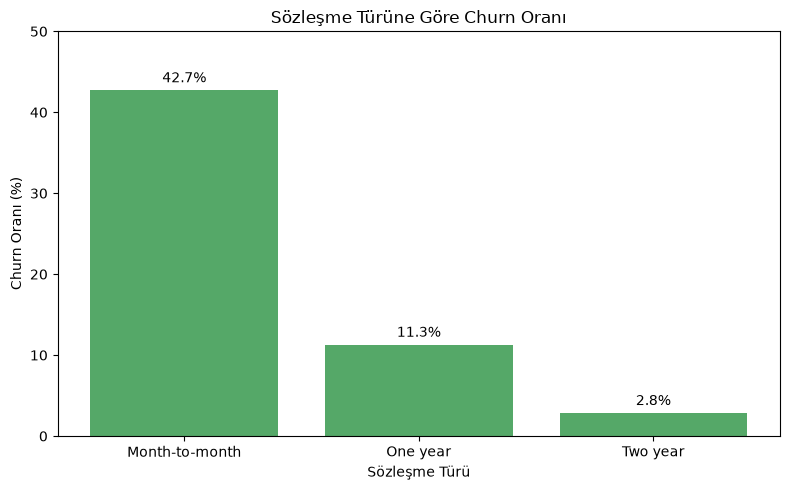

In [15]:
contract_order = ["Month-to-month", "One year", "Two year"]
contract_churn_rate = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"]
    .reindex(contract_order)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn_rate.index, contract_churn_rate.values, color=rate_color)

for bar, value in zip(bars, contract_churn_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center")

ax.set_title("Sözleşme Türüne Göre Churn Oranı")
ax.set_xlabel("Sözleşme Türü")
ax.set_ylabel("Churn Oranı (%)")
ax.set_ylim(0, 50)
fig.tight_layout()
fig.savefig(figures_dir / "contract_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

Bu veri setinde aylık sözleşmesi olan müşterilerde churn oranı %42,7'dir. Bir yıllık (%11,3) ve iki yıllık (%2,8) sözleşme gruplarında daha düşük oranlar gözlenmektedir; bu, veri setindeki gözlenen bir ilişkidir.

## Tenure ile Churn İlişkisi

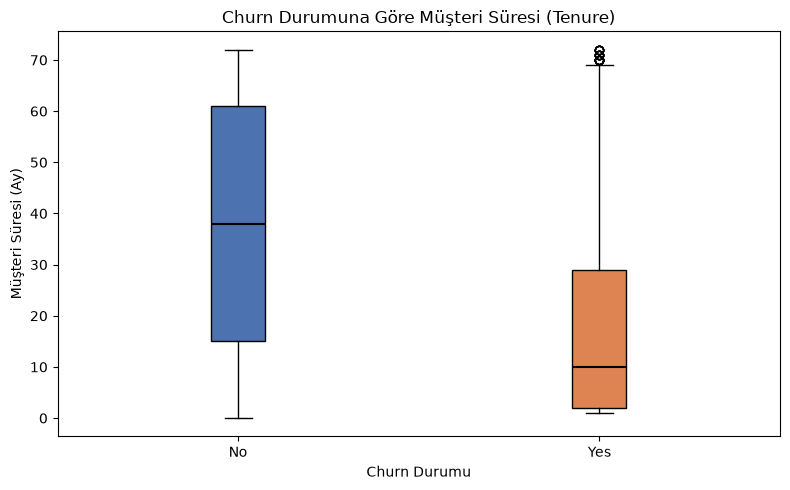

In [16]:
tenure_by_churn = [
    df.loc[df["Churn"] == status, "tenure"]
    for status in churn_order
]

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    tenure_by_churn,
    tick_labels=churn_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
)

for patch, status in zip(box["boxes"], churn_order):
    patch.set_facecolor(churn_colors[status])

ax.set_title("Churn Durumuna Göre Müşteri Süresi (Tenure)")
ax.set_xlabel("Churn Durumu")
ax.set_ylabel("Müşteri Süresi (Ay)")
fig.tight_layout()
fig.savefig(figures_dir / "tenure_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

Churn eden müşterilerin tenure dağılımı daha düşük değerlere kaymaktadır. Medyan müşteri süresi churn edenlerde 10 ay, churn etmeyenlerde 38 aydır.

## MonthlyCharges ile Churn İlişkisi

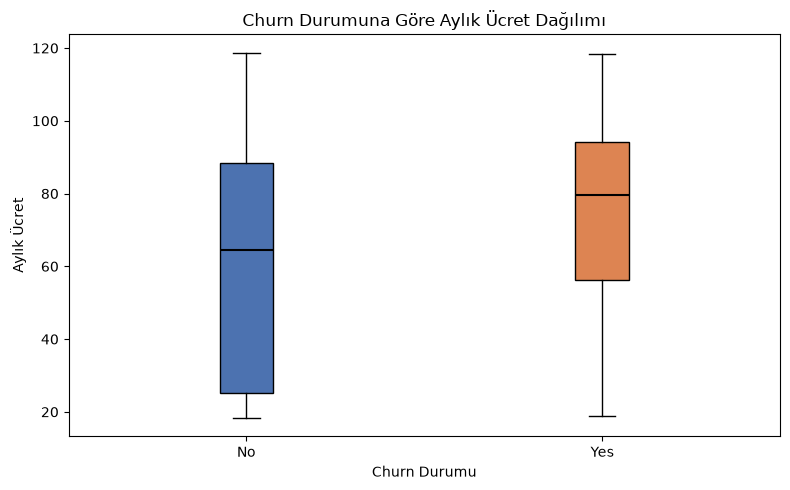

In [17]:
monthly_charges_by_churn = [
    df.loc[df["Churn"] == status, "MonthlyCharges"]
    for status in churn_order
]

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    monthly_charges_by_churn,
    tick_labels=churn_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
)

for patch, status in zip(box["boxes"], churn_order):
    patch.set_facecolor(churn_colors[status])

ax.set_title("Churn Durumuna Göre Aylık Ücret Dağılımı")
ax.set_xlabel("Churn Durumu")
ax.set_ylabel("Aylık Ücret")
fig.tight_layout()
fig.savefig(figures_dir / "monthly_charges_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

Churn eden müşterilerin aylık ücret dağılımının merkezi daha yüksektir. Medyan aylık ücret churn edenlerde 79,65 iken churn etmeyenlerde 64,43'tür; iki grubun dağılımları yine de kısmen örtüşmektedir.

## InternetService ile Churn İlişkisi

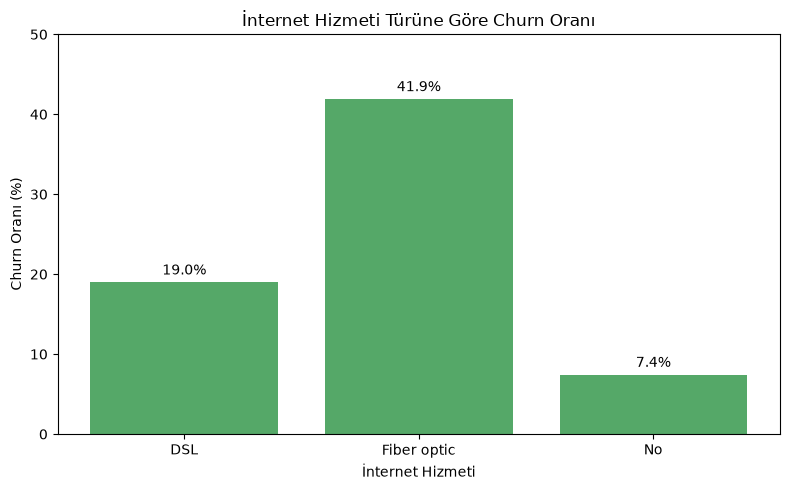

In [18]:
internet_service_order = ["DSL", "Fiber optic", "No"]
internet_service_churn_rate = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index")["Yes"]
    .reindex(internet_service_order)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(internet_service_churn_rate.index, internet_service_churn_rate.values, color=rate_color)

for bar, value in zip(bars, internet_service_churn_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center")

ax.set_title("İnternet Hizmeti Türüne Göre Churn Oranı")
ax.set_xlabel("İnternet Hizmeti")
ax.set_ylabel("Churn Oranı (%)")
ax.set_ylim(0, 50)
fig.tight_layout()
fig.savefig(figures_dir / "internet_service_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

Fiber optic hizmeti kullanan grupta churn oranı %41,9 ile en yüksektir. DSL grubunda %19,0, internet hizmeti olmayan grupta ise %7,4 churn oranı gözlenmektedir.

## PaymentMethod ile Churn İlişkisi

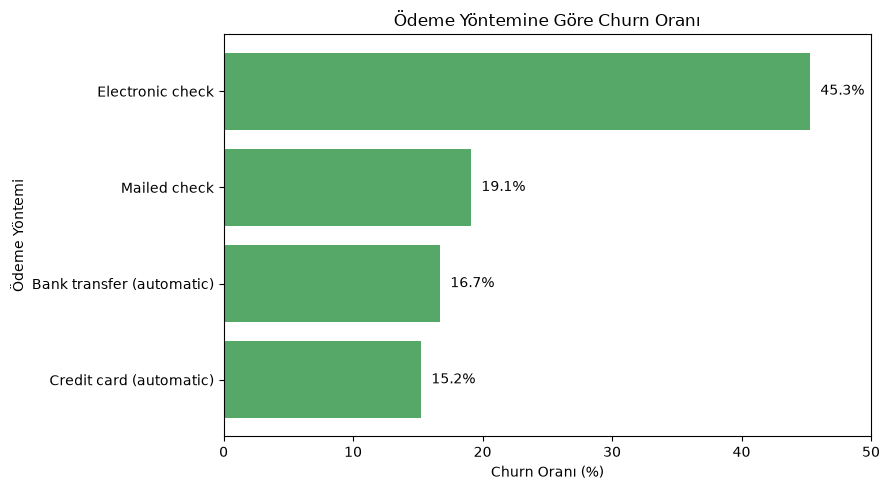

In [19]:
payment_method_order = [
    "Electronic check",
    "Mailed check",
    "Bank transfer (automatic)",
    "Credit card (automatic)",
]
payment_method_churn_rate = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")["Yes"]
    .reindex(payment_method_order)
    .mul(100)
)
payment_method_labels = [
    "Electronic check",
    "Mailed check",
    "Bank transfer (automatic)",
    "Credit card (automatic)",
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    payment_method_labels[::-1],
    payment_method_churn_rate.values[::-1],
    color=rate_color,
)

for bar, value in zip(bars, payment_method_churn_rate.values[::-1]):
    ax.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center")

ax.set_title("Ödeme Yöntemine Göre Churn Oranı")
ax.set_xlabel("Churn Oranı (%)")
ax.set_ylabel("Ödeme Yöntemi")
ax.set_xlim(0, 50)
fig.tight_layout()
fig.savefig(figures_dir / "payment_method_churn.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

Electronic check kullanan müşterilerde churn oranı %45,3 ile diğer ödeme yöntemlerinden daha yüksektir. Diğer üç ödeme yönteminde gözlenen churn oranları %15,2 ile %19,1 arasındadır.

### Görselleştirmelerden Çıkan Bulgular

- Churn etmeyen müşteriler veri setinde çoğunluktadır; churn edenler toplam müşterilerin yaklaşık dörtte birini oluşturur.
- Aylık sözleşme grubunda, bir ve iki yıllık sözleşme gruplarına göre daha yüksek churn oranı gözlenmektedir.
- Churn eden müşterilerin müşteri süresi dağılımı daha düşük aylarda yoğunlaşmaktadır.
- Churn eden müşterilerin aylık ücret dağılımının medyanı churn etmeyen gruptan daha yüksektir.
- Fiber optic internet hizmeti ve Electronic check ödeme yöntemi gruplarında daha yüksek churn oranları görülmektedir.
- Bu grafikler değişkenler arasında gözlenen farklılıkları gösterir; neden-sonuç ilişkisi kurmaz.

# 5. Veri Ön İşleme

Makine öğrenmesi modeli kurulmadan önce verinin model tarafından kullanılabilecek bir biçime getirilmesi gerekir. Bu bölümde problemli değerler düzeltilir, anlamlı olmayan kimlik sütunu çıkarılır, kategorik bilgiler sayısallaştırılır ve veri eğitim/test kümelerine ayrılır.

## Ham Verinin Kopyalanması ve TotalCharges Düzenlemesi

In [20]:
df_preprocessed = df.copy()

df_preprocessed["TotalCharges"] = pd.to_numeric(
    df_preprocessed["TotalCharges"].str.strip(),
    errors="coerce",
)

total_charges_missing = df_preprocessed["TotalCharges"].isna().sum()
print(f"TotalCharges dönüşümü sonrası eksik değer sayısı: {total_charges_missing}")

df_preprocessed = df_preprocessed.dropna(subset=["TotalCharges"]).copy()
print(f"Problemli satırlar çıkarıldıktan sonraki veri seti boyutu: {df_preprocessed.shape}")

TotalCharges dönüşümü sonrası eksik değer sayısı: 11
Problemli satırlar çıkarıldıktan sonraki veri seti boyutu: (7032, 21)


`TotalCharges` sütunundaki 11 yalnızca boşluk içeren değer sayısala dönüştürüldüğünde eksik değer oldu. Bu kayıtlar toplam veri setinin yaklaşık %0,16'sını oluşturur ve toplam ücret bilgisini güvenilir biçimde doldurmak için ek bir bilgi yoktur. Bu nedenle bu 11 satır çıkarılmıştır. İşlemler ham CSV üzerinde değil, `df_preprocessed` kopyasında yapılmıştır.

## Kimlik Sütununun Çıkarılması ve Hedefin Ayrılması

In [21]:
model_df = df_preprocessed.drop(columns=["customerID"]).copy()
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1}).astype("int64")

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print(f"X boyutu: {X.shape}")
print(f"y boyutu: {y.shape}")
print(f"y benzersiz değerleri: {[int(value) for value in sorted(y.unique())]}")

X boyutu: (7032, 19)
y boyutu: (7032,)
y benzersiz değerleri: [0, 1]


`customerID` her müşteri için benzersiz bir kimliktir; müşteri davranışını açıklayan bir özellik olmadığı için modelleme verisinden çıkarılmıştır. Hedef değişken `Churn`, `No → 0` ve `Yes → 1` olacak şekilde sayısal hale getirilmiştir.

## Kategorik Değişkenlerin One-Hot Encoding ile Dönüştürülmesi

In [22]:
categorical_columns = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_columns, dtype=int)

print(f"Dönüştürülen kategorik sütun sayısı: {len(categorical_columns)}")
print(f"Encoding sonrası toplam özellik sayısı: {X.shape[1]}")
print(f"Encoding sonrası X boyutu: {X.shape}")

Dönüştürülen kategorik sütun sayısı: 15
Encoding sonrası toplam özellik sayısı: 45
Encoding sonrası X boyutu: (7032, 45)


One-hot encoding, kategorik değerleri ayrı 0/1 sütunlarına dönüştürür. Böylece model kategorileri sayısal bir sıra varmış gibi yorumlamadan kullanabilir.

## Train/Test Split ve Sayısal Özelliklerin Ölçeklendirilmesi

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

scale_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train = X_train.copy()
X_test = X_test.copy()
X_train[scale_columns] = X_train[scale_columns].astype("float64")
X_test[scale_columns] = X_test[scale_columns].astype("float64")

scaler = StandardScaler()
X_train.loc[:, scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test.loc[:, scale_columns] = scaler.transform(X_test[scale_columns])

split_summary = pd.DataFrame({
    "Küme": ["Eğitim", "Test"],
    "Özellik Boyutu": [X_train.shape, X_test.shape],
    "Hedef Boyutu": [y_train.shape, y_test.shape],
    "Churn Oranı (%)": [(y_train.mean() * 100).round(2), (y_test.mean() * 100).round(2)],
})

split_summary

,Küme,Özellik Boyutu,Hedef Boyutu,Churn Oranı (%)
0,Eğitim,"(5625, 45)","(5625,)",26.58
1,Test,"(1407, 45)","(1407,)",26.58


Veri %80 eğitim ve %20 test olarak ayrılmıştır. `stratify=y`, churn sınıf oranının iki kümede de benzer kalmasını sağlar. `StandardScaler` yalnızca eğitim verisi üzerinde `fit` edilmiştir; test verisine yalnızca `transform` uygulanmıştır. Bu yaklaşım test bilgisinin eğitim sürecine sızmasını önler. Dummy değişkenler ölçeklendirilmemiştir.

## Preprocessing Sonucu Kontrolleri

In [24]:
preprocessing_checks = pd.DataFrame({
    "Kontrol": [
        "Eğitim kümesinde eksik değer yok",
        "Test kümesinde eksik değer yok",
        "Tüm özellikler sayısal",
        "Eğitim ve test sütunları aynı",
        "Hedef yalnızca 0 ve 1 içeriyor",
        "Train/test oranı yaklaşık %80/%20",
        "Stratification sonrası churn oranları yakın",
    ],
    "Sonuç": [
        X_train.isna().sum().sum() == 0,
        X_test.isna().sum().sum() == 0,
        all(pd.api.types.is_numeric_dtype(dtype) for dtype in X_train.dtypes),
        X_train.columns.equals(X_test.columns),
        set(y.unique()) == {0, 1},
        round(len(X_train) / len(X), 2) == 0.80 and round(len(X_test) / len(X), 2) == 0.20,
        abs(y_train.mean() - y_test.mean()) < 0.01,
    ],
})

preprocessing_checks

,Kontrol,Sonuç
0,Eğitim kümesinde eksik değer yok,True
1,Test kümesinde eksik değer yok,True
2,Tüm özellikler sayısal,True
3,Eğitim ve test sütunları aynı,True
4,Hedef yalnızca 0 ve 1 içeriyor,True
5,Train/test oranı yaklaşık %80/%20,True
6,Stratification sonrası churn oranları yakın,True


### Veri Ön İşleme Özeti

- `TotalCharges` sayısal tipe dönüştürüldü; boşluk içeren 11 problemli satır çıkarıldı.
- Benzersiz kimlik bilgisi olan `customerID` modelleme verisinden çıkarıldı.
- `Churn`, `No → 0` ve `Yes → 1` olarak dönüştürüldü.
- Kategorik değişkenler one-hot encoding ile sayısallaştırıldı.
- Veri, stratification kullanılarak %80 eğitim ve %20 test kümelerine ayrıldı.
- `tenure`, `MonthlyCharges` ve `TotalCharges` sütunları eğitim verisi üzerinde StandardScaler ile ölçeklendirildi; test verisine yalnızca dönüşüm uygulandı.
- Modelleme için eksik değeri olmayan ve tamamen sayısal özelliklerden oluşan `X_train`, `X_test`, `y_train` ve `y_test` hazırlandı.

# 6. Modelin Oluşturulması

Logistic Regression, bir gözlemin belirli bir sınıfa ait olma olasılığını tahmin etmek için kullanılan basit ve yaygın bir sınıflandırma yöntemidir. İki sınıflı `Churn` problemi için uygun, anlaşılır ve iyi bir başlangıç modeli olduğundan bu projede kullanılmaktadır.

In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

print(f"Model eğitimde kullanılan örnek sayısı: {X_train.shape[0]}")
print(f"Modelin yakınsama iterasyon sayısı: {logistic_model.n_iter_[0]}")

Model eğitimde kullanılan örnek sayısı: 5625
Modelin yakınsama iterasyon sayısı: 37


`.fit()` işlemi, Logistic Regression modelinin eğitim verisindeki özellikler ile churn etiketi arasındaki deseni öğrenmesini sağlar. Model yalnızca `X_train` ve `y_train` kullanılarak eğitilmiştir.

# 7. Modelin Değerlendirilmesi

## Test Tahminleri ve Accuracy

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = logistic_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

assert len(y_pred) == len(y_test)
assert set(y_pred).issubset({0, 1})

print(f"Tahmin edilen sınıflar: {[int(value) for value in sorted(set(y_pred))]}")
print(f"Tahmin sayısı: {len(y_pred)}")
print(f"Accuracy: {test_accuracy:.4f} (%{test_accuracy * 100:.2f})")

Tahmin edilen sınıflar: [0, 1]
Tahmin sayısı: 1407
Accuracy: 0.8045 (%80.45)


Accuracy, modelin tüm test örnekleri içindeki doğru tahmin oranını gösterir. Churn sınıfları tam dengeli olmadığı için accuracy tek başına model performansını açıklamak için yeterli değildir; churn eden müşterilere ait metrikler de incelenmelidir.

## Classification Report

In [27]:
classification_results = classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    output_dict=True,
)

classification_report_table = pd.DataFrame(classification_results).T.round(4)
classification_report_table

,precision,recall,f1-score,support
No Churn,0.8522,0.8877,0.8696,1033.0000
Churn,0.6495,0.5749,0.6099,374.0000
accuracy,0.8045,0.8045,0.8045,0.8045
macro avg,0.7509,0.7313,0.7398,1407.0000
weighted avg,0.7984,0.8045,0.8006,1407.0000


- **Precision**, modelin churn olarak tahmin ettiği müşterilerin ne kadarının gerçekten churn ettiğini gösterir.
- **Recall**, gerçekten churn eden müşterilerin ne kadarının model tarafından yakalandığını gösterir.
- **F1-score**, precision ve recall değerlerini birlikte özetleyen bir ölçüdür.

Churn sınıfında precision, recall ve F1-score değerleri değerlendirilerek modelin ayrılacak müşterileri yakalama performansı incelenir.

## Confusion Matrix

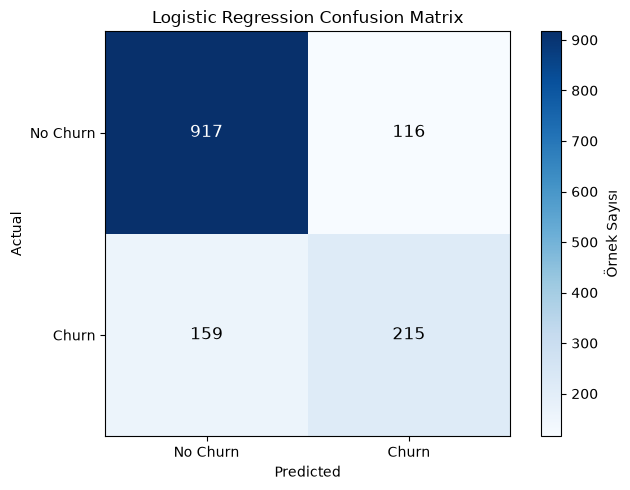

,Değer
True Negative,917
False Positive,116
False Negative,159
True Positive,215


In [28]:
confusion_matrix_values = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = confusion_matrix_values.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(confusion_matrix_values, cmap="Blues")
fig.colorbar(image, ax=ax, label="Örnek Sayısı")

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], labels=["No Churn", "Churn"])
ax.set_yticks([0, 1], labels=["No Churn", "Churn"])

threshold = confusion_matrix_values.max() / 2
for row_index in range(confusion_matrix_values.shape[0]):
    for column_index in range(confusion_matrix_values.shape[1]):
        value = confusion_matrix_values[row_index, column_index]
        color = "white" if value > threshold else "black"
        ax.text(column_index, row_index, str(value), ha="center", va="center", color=color, fontsize=12)

fig.tight_layout()
fig.savefig(figures_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

confusion_matrix_summary = pd.DataFrame({
    "Değer": [tn, fp, fn, tp],
}, index=["True Negative", "False Positive", "False Negative", "True Positive"])
confusion_matrix_summary

- **True Negative (TN)**: Gerçekte churn etmeyen ve modelin de churn etmeyecek olarak tahmin ettiği müşteriler.
- **False Positive (FP)**: Gerçekte churn etmeyen ancak modelin churn edecek olarak tahmin ettiği müşteriler.
- **False Negative (FN)**: Gerçekte churn edecek bir müşterinin model tarafından churn etmeyecek olarak tahmin edilmesi.
- **True Positive (TP)**: Gerçekte churn eden ve modelin de churn edecek olarak tahmin ettiği müşteriler.

Churn problemi açısından false negative değerleri, ayrılma riski taşıdığı halde modelin gözden kaçırdığı müşterileri temsil eder.

## Majority-Class Baseline Karşılaştırması

In [29]:
baseline_predictions = [0] * len(y_test)
majority_class_baseline_accuracy = accuracy_score(y_test, baseline_predictions)

baseline_comparison = pd.DataFrame({
    "Yaklaşım": ["Majority-class baseline (her zaman No Churn)", "Logistic Regression"],
    "Accuracy": [majority_class_baseline_accuracy, test_accuracy],
    "Accuracy (%)": [majority_class_baseline_accuracy * 100, test_accuracy * 100],
})

baseline_comparison.round(4)

,Yaklaşım,Accuracy,Accuracy (%)
0,Majority-class baseline (her zaman No Churn),0.7342,73.4186
1,Logistic Regression,0.8045,80.4549


## Sonuç Tutarlılığı Kontrolleri

In [30]:
model_checks = pd.DataFrame({
    "Kontrol": [
        "Tahmin sayısı test örnek sayısına eşit",
        "Tahminler yalnızca 0 ve 1 içeriyor",
        "Confusion matrix toplamı test örnek sayısına eşit",
        "Classification report support toplamı 1407",
        "Accuracy confusion matrix ile tutarlı",
        "Model eğitim özellik sayısı X_train ile eşit",
    ],
    "Sonuç": [
        len(y_pred) == len(y_test),
        set(y_pred).issubset({0, 1}),
        confusion_matrix_values.sum() == len(y_test),
        classification_results["No Churn"]["support"] + classification_results["Churn"]["support"] == len(y_test),
        abs(test_accuracy - ((tn + tp) / confusion_matrix_values.sum())) < 1e-12,
        logistic_model.n_features_in_ == X_train.shape[1],
    ],
})

model_checks

,Kontrol,Sonuç
0,Tahmin sayısı test örnek sayısına eşit,True
1,Tahminler yalnızca 0 ve 1 içeriyor,True
2,Confusion matrix toplamı test örnek sayısına eşit,True
3,Classification report support toplamı 1407,True
4,Accuracy confusion matrix ile tutarlı,True
5,Model eğitim özellik sayısı X_train ile eşit,True


### Model Performansı

- Logistic Regression test setinde %80,45 accuracy elde etti.
- Churn sınıfı için precision yaklaşık %64,95, recall yaklaşık %57,49 ve F1-score yaklaşık %60,99'dur.
- Model, her müşteriye `No Churn` diyen baseline'ın %73,42 accuracy değerinin üzerine çıktı.
- Model testteki 374 churn müşterisinin 215 tanesini doğru yakaladı; 159 churn müşterisi false negative olarak gözden kaçtı.
- Sınıflar dengeli olmadığı için %80,45 accuracy tek başına yeterli değildir; churn sınıfındaki recall ve false negative sayısı da dikkate alınmalıdır.

# 8. Sonuç ve Yorumlar

Bu aşamada Logistic Regression ile temel bir başlangıç modeli kuruldu. Model, majority-class baseline'dan daha yüksek accuracy elde etti; ancak churn eden müşterilerin bir kısmını kaçırdığı için sonuçlar sonraki aşamalarda daha ayrıntılı yorumlanabilir.